<a href="https://colab.research.google.com/github/cvinushareddy/Data-science-projects/blob/main/Week_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



**Name:** C Vinusha Reddy

**USN:** 1CR22IS036  

**Task:** Task-4  

**Week:** 10


#  Project Title  
### Potato Leaf Disease Detection using Image Classification

#  Project Description
This project focuses on building an image classification model to detect and classify potato plant diseases.  
The dataset consists of high-resolution images of potato leaves categorized into three classes:  
Early Blight, Late Blight, and Healthy leaves.  

The goal is to develop a robust deep learning model that can accurately identify plant diseases and support agricultural diagnostics.

#  Objectives
- Understand image classification using deep learning  
- Perform data preprocessing and augmentation  
- Train and evaluate a CNN-based model  

#  Dataset Details
## Classes:
- Early Blight  
- Late Blight  
- Healthy  

## Data Type:
Image dataset (high-resolution leaf images)

###**1. Data Understanding**

In [4]:
import kagglehub
import os
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd

# Download latest version
path = kagglehub.dataset_download("hafiznouman786/potato-plant-diseases-data")
print("Path to dataset files:", path)

# List classes and count images
classes = [f for f in os.listdir(path) if os.path.isdir(os.path.join(path, f))]
for x in classes:
    count = len(os.listdir(os.path.join(path, x)))
    print(f"{x} --> {count}")

# Visualize sample images
plt.figure(figsize=(12, 5))
for i, class_name in enumerate(classes):
    class_path = os.path.join(path, class_name)

    # Initialize a list to hold all image files found for this class
    all_img_files_for_class = []

    # Iterate through each item in the class_path to find actual images
    for item in os.listdir(class_path):
        item_path = os.path.join(class_path, item)
        if os.path.isdir(item_path):
            # If it's a directory, list its contents and filter for images
            img_files_in_subdir = [f for f in os.listdir(item_path) if os.path.isfile(os.path.join(item_path, f)) and f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))]
            all_img_files_for_class.extend([os.path.join(item_path, f) for f in img_files_in_subdir])
        elif os.path.isfile(item_path) and item.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
            # If it's a file and an image, add it directly (though less common in this dataset)
            all_img_files_for_class.append(item_path)

    if all_img_files_for_class:
        # Take the first image found for visualization
        img_full_path = all_img_files_for_class[0]
        img = Image.open(img_full_path)
        plt.subplot(1, len(classes), i + 1)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis('off')
    else:
        print(f"No image files found for class {class_name} in {class_path} or its immediate subdirectories.")

plt.tight_layout()
plt.show()

Using Colab cache for faster access to the 'potato-plant-diseases-data' dataset.
Path to dataset files: /kaggle/input/potato-plant-diseases-data
PlantVillage --> 1
PotatoPlants --> 3
No image files found in /kaggle/input/potato-plant-diseases-data/PlantVillage/PlantVillage for class PlantVillage
No image files found in /kaggle/input/potato-plant-diseases-data/PotatoPlants for class PotatoPlants


<Figure size 1200x500 with 0 Axes>

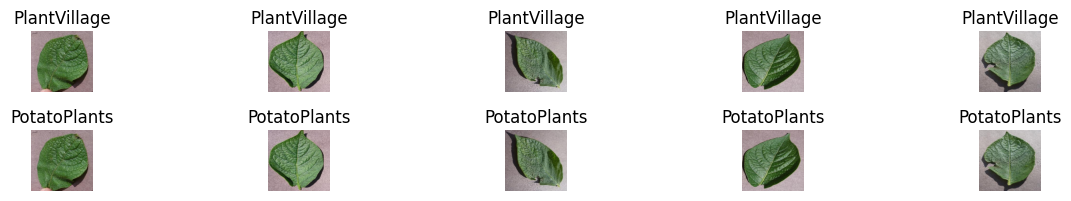

In [12]:
import matplotlib.pyplot as plt
from PIL import Image #Python image library

plt.figure(figsize=(12,10))
i = 1
for class_name in classes: # Use `classes` to ensure we iterate through valid class names
  class_root_path = os.path.join(path, class_name) # Start at the root for this class

  all_img_files_for_class = []
  for dirpath, dirnames, filenames in os.walk(class_root_path):
    for img_name in filenames:
      if img_name.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
        all_img_files_for_class.append(os.path.join(dirpath, img_name))

  # Take up to 5 images for visualization
  images_to_display = all_img_files_for_class[:5]

  for img_full_path in images_to_display:
    try:
      img = Image.open(img_full_path)

      plt.subplot(10,5,i)
      plt.imshow(img)
      plt.title(class_name)
      plt.axis('off')

      i+=1
    except Exception as e:
      print(f"Could not open image {img_full_path}: {e}")

plt.tight_layout()
plt.show()

###**2. Data Preprocessing**

In [13]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Create DataFrame
df_list = []
for label in classes:
    class_root_path = os.path.join(path, label)
    for dirpath, dirnames, filenames in os.walk(class_root_path):
        for img_name in filenames:
            if img_name.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
                img_full_path = os.path.join(dirpath, img_name)
                df_list.append([img_full_path, label])

data = pd.DataFrame(df_list, columns=['img_path', 'label']).sample(frac=1, random_state=42)

# Split data: 70% Train, 15% Val, 15% Test
train_idx = int(0.7 * len(data))
val_idx = int(0.85 * len(data))

train_df = data.iloc[:train_idx]
val_df = data.iloc[train_idx:val_idx]
test_df = data.iloc[val_idx:]

# Normalization and Augmentation
img_height, img_width = 128, 128
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Only rescaling for validation and test
test_datagen = ImageDataGenerator(rescale=1.0/255)

train_generator = train_datagen.flow_from_dataframe(
    train_df, x_col='img_path', y_col='label',
    target_size=(img_height, img_width), batch_size=batch_size, class_mode='categorical'
)

val_generator = test_datagen.flow_from_dataframe(
    val_df, x_col='img_path', y_col='label',
    target_size=(img_height, img_width), batch_size=batch_size, class_mode='categorical'
)

test_generator = test_datagen.flow_from_dataframe(
    test_df, x_col='img_path', y_col='label',
    target_size=(img_height, img_width), batch_size=batch_size, class_mode='categorical',
    shuffle=False # Important for Confusion Matrix
)

Found 3012 validated image filenames belonging to 2 classes.
Found 646 validated image filenames belonging to 2 classes.
Found 646 validated image filenames belonging to 2 classes.


###**3. Model Building AND 4.Model Training**

In [14]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(len(classes), activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)

Epoch 1/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 109s 1s/step - accuracy: 0.5043 - loss: 0.7200 - val_accuracy: 0.5077 - val_loss: 0.6931
Epoch 2/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.4897 - loss: 0.6934 - val_accuracy: 0.4923 - val_loss: 0.6934
Epoch 3/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.4857 - loss: 0.6934 - val_accuracy: 0.4923 - val_loss: 0.6935
Epoch 4/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.5053 - loss: 0.6932 - val_accuracy: 0.4923 - val_loss: 0.6933
Epoch 5/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 103s 1s/step - accuracy: 0.4977 - loss: 0.6937 - val_accuracy: 0.4923 - val_loss: 0.6939
Epoch 6/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 107s 1s/step - accuracy: 0.5053 - loss: 0.6932 - val_accuracy: 0.4923 - val_loss: 0.6934
Epoch 7/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 106s 1s/step - accuracy: 0.5053 - loss: 0.6932 - val_accuracy: 0.4923 - val_loss: 0.6933
Epoch 8/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 105s 1s/step - accuracy: 0.5053 - loss: 0.6932 - val_accuracy: 0.4923 - v

###**5. Model Evaluation**

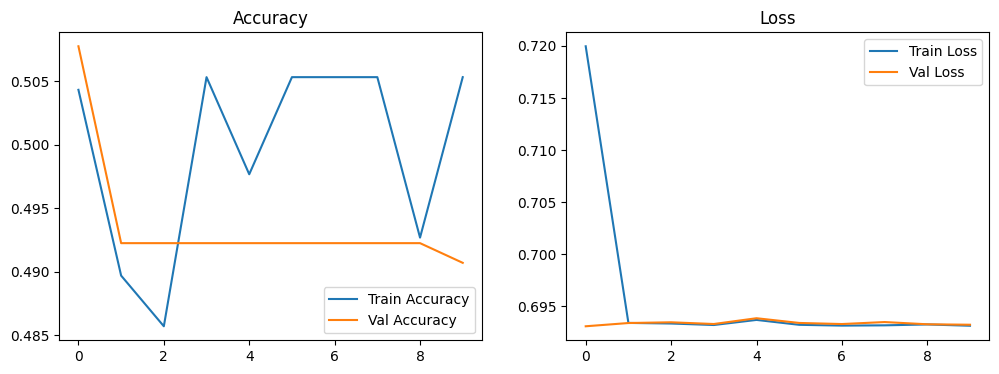

21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 308ms/step


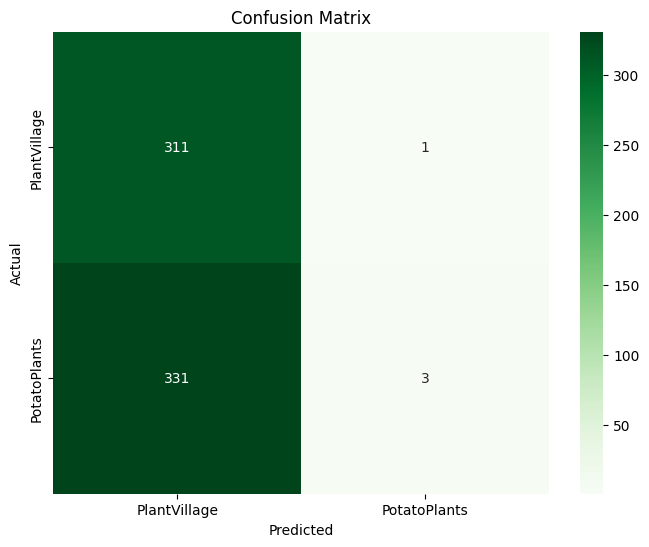


Classification Report:
              precision    recall  f1-score   support

PlantVillage       0.48      1.00      0.65       312
PotatoPlants       0.75      0.01      0.02       334

    accuracy                           0.49       646
   macro avg       0.62      0.50      0.33       646
weighted avg       0.62      0.49      0.32       646



In [15]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

# 1. Overall Accuracy and Loss Plots
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')
plt.show()

# 2. Confusion Matrix
Y_pred = model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# 3. Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=classes))